# Parsho package tutorial

This notebook demonstrates a Parsho workflow from raw three-channel TIFF images through cell measurements and nucleus-centered, cell-shape-adapted radial aggregate analysis. It uses the package's segmentation, mask-filtering, plotting, and distribution functions directly. 

The filename convention used here is `C1-<name>` for nuclei, `C2-<name>` for aggregates, and `C3-<name>` for cell membrane. Adjust the paths and filename helpers if your images use another naming convention.

In [19]:
# Necessary imports.
from pathlib import Path
import numpy as np
import pandas as pd
from cellpose import core, models
import cellpose.utils as utils_cell

from parsho.distribution import (
    compute_nucleus_centered_distribution,
    nucleus_centroids_by_cell,
)
from parsho.utils import (
    radial_distributions_to_records
)
from parsho.maskfilters import (
    build_overlay,
    compute_cell_metrics,
    filter_cells_by_overlap,
    mask_overlay_to_transfected,
    subtract_nuclear_from_aggregate,
)
from parsho.plotting import (
    plot_aggregate_channel,
    plot_aggregate_channel_color,
    plot_aggregate_channel_color_labelled,
    plot_nucleus_centered_distribution,
    plot_segmentation_result,
)
from parsho.segmentation import (
    extract_masks,
    find_optimal_threshold,
    re_threshold_masks,
)
from parsho.img_utils import (
    load_image
)


## Configuration

Parameters configuration for the run including control images and desired parameters for CellPose (Add guidelines)

In [18]:
# Folder path to results and data. Change this to your own path if you are running the tutorial outside of the parsho package.
PROJECT_DIR = Path.cwd() / "data" 
DATA_DIR = PROJECT_DIR / "aggregates" # For example, you can replace PROJECT_DIR / "aggregates" with "C:/path/to/your/data"
RESULTS_DIR = PROJECT_DIR / "tutorial_results"
INSPECTION_DIR = RESULTS_DIR / "inspection_images" # This will generate a folder with inspection images for each step of the analysis. 
CELL_CSV = RESULTS_DIR / "final_data.csv"
RADIAL_CSV = RESULTS_DIR / "radial_distribution.csv"

# Parameters for the control images and radial aggregate distribution analysis.
POSITIVE_NAME = "positive_control.tif"  # Shared suffix after C1-/C2-/C3-.
NEGATIVE_NAME = "negative_control.tif"
RADIAL_BINS = 10 # A value of 10 means that the radial distribution will be computed in 10 concentric rings around the nucleus.

# Common Cellpose parameters used for control images and the batch of images. For more information on these parameters, see the Cellpose documentation.
CELLPOSE_PARAMETERS = {
    "batch_size": 32,
    "diameter": None,  # Expected cell diameter in pixels.
    "flow_threshold": 0.0,
    "cellprob_threshold": -2.0,
    "min_size": 15, # Minimum expected size of cells in pixels. This is used to filter out small objects that are unlikely to be cells.
    "normalize": {"tile_norm_blocksize": 0},
}
GPU = core.use_gpu()

INSPECTION_DIR.mkdir(parents=True, exist_ok=True)
print(f"Using GPU: {GPU}")


Using GPU: True


In [3]:
# Load CellPoseSAM
model = models.CellposeModel(gpu=GPU)

## Image loading 

The aggregate channel is kept at its original intensity scale for quantitative measurements.

In [20]:
# Function to load image sets
def load_image_set(data_dir: Path, name: str) -> tuple[np.ndarray, ...]:
    """Load cell, aggregate, and nuclear channels for one image set."""
    img_cell = load_image(data_dir / f"C3-{name}") # Load the cell membrane channel (C3) image. Change the name if your images use a different name convention.
    img_aggregates = load_image(data_dir / f"C2-{name}") # Load the aggregates channel (C2) image. Change the name if your images use a different name convention.
    img_nuclei = load_image(data_dir / f"C1-{name}") # Load the cell nuclei channel (C1) image. Change the name if your images use a different name convention.
    return img_cell, img_aggregates, img_nuclei

## Calibrate the aggregate threshold

This calibration step estimates Otsu thresholds for positive and negative controls, excludes nuclear signal, and searches for a fixed aggregate threshold that retains positive signal without negative signal.

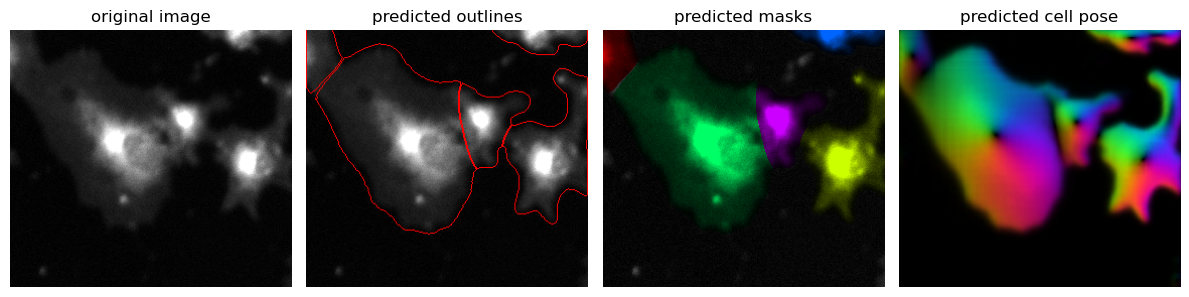

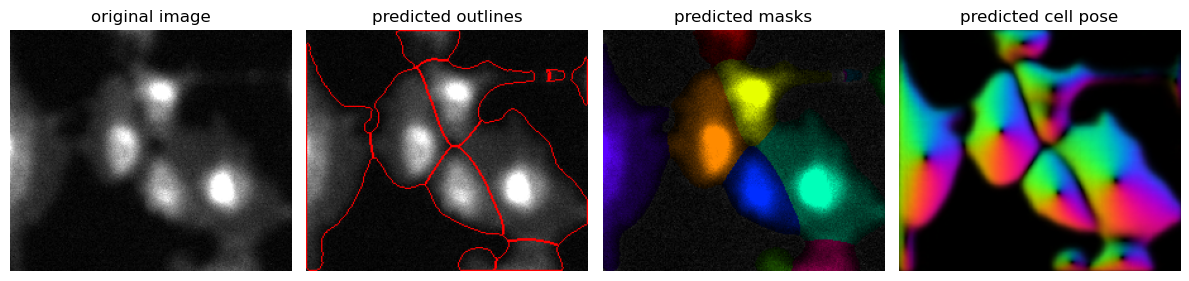

In [21]:
pos_img_cell, pos_img_aggregates, pos_img_nuclei = load_image_set(
    DATA_DIR, POSITIVE_NAME
)
neg_img_cell, neg_img_aggregates, neg_img_nuclei = load_image_set(
    DATA_DIR, NEGATIVE_NAME
)

pos_masks, pos_flows, _ = model.eval(pos_img_cell, **CELLPOSE_PARAMETERS)
neg_masks, neg_flows, _ = model.eval(neg_img_cell, **CELLPOSE_PARAMETERS)

plot_segmentation_result(pos_img_cell, pos_masks, pos_flows)
plot_segmentation_result(neg_img_cell, neg_masks, neg_flows)


In [22]:
pos_agg_binary, pos_agg_labels, pos_agg_threshold = extract_masks(
    aggregate_channel=pos_img_aggregates,
    cell_masks=pos_masks,
    method="otsu", # Otsu method is used. If you want to use a different method, you can change this parameter. Other methods include "adaptive" and "manual".
    min_size_px=2, # Minimum size of aggregates in pixels. Aggregates smaller than this size will be ignored. You can change this parameter based on your data.
    scale=1,
)
neg_agg_binary, neg_agg_labels, neg_agg_threshold = extract_masks(
    aggregate_channel=neg_img_aggregates,
    cell_masks=neg_masks,
    method="otsu", # Otsu method is used. If you want to use a different method, you can change this parameter. Other methods include "adaptive" and "manual".
    min_size_px=2, # Minimum size of aggregates in pixels. Aggregates smaller than this size will be ignored. You can change this parameter based on your data.
    scale=1,
)
pos_nuc_binary, pos_nuc_labels, _ = extract_masks(
    aggregate_channel=pos_img_nuclei,
    cell_masks=pos_masks,
    method="otsu", # Otsu method is used. If you want to use a different method, you can change this parameter. Other methods include "adaptive" and "manual".
    min_size_px=5, # Minimum size of nuclei in pixels. Nuclei smaller than this size will be ignored. You can change this parameter based on your data.
    scale=1,
)
neg_nuc_binary, neg_nuc_labels, _ = extract_masks(
    aggregate_channel=neg_img_nuclei,
    cell_masks=neg_masks,
    method="otsu", # Otsu method is used. If you want to use a different method, you can change this parameter. Other methods include "adaptive" and "manual".
    min_size_px=5, # Minimum size of nuclei in pixels. Nuclei smaller than this size will be ignored. You can change this parameter based on your data.
    scale=1,
)

optimal_threshold, positive_pixels = find_optimal_threshold(
    pos_img_aggregates,
    pos_masks,
    neg_img_aggregates,
    neg_masks,
    pos_nuc_binary,
    neg_nuc_binary,
    t_min=neg_agg_threshold,
    t_max=pos_agg_threshold,
)
print(f"Optimal aggregate threshold: {optimal_threshold}")
print(f"Positive pixels at threshold: {positive_pixels}")


Optimal aggregate threshold: 797.6908569335938
Positive pixels at threshold: 1639


## Walk through one image set

Before running the batch, inspect one complete image set. The following cells displays the Cellpose segmentation, binary channel masks, categorical overlay, filtered labeled overlay, and nucleus-centered shape-adapted radial diagnostic using the plotting functions provided by Parsho.
This can be used to quickly spot artifacts or inadecuate parameters.

In this notebook all images follow the same naming convention with `C1-<name>` for nuclei, `C2-<name>` for aggregates, and `C3-<name>` for cells. 

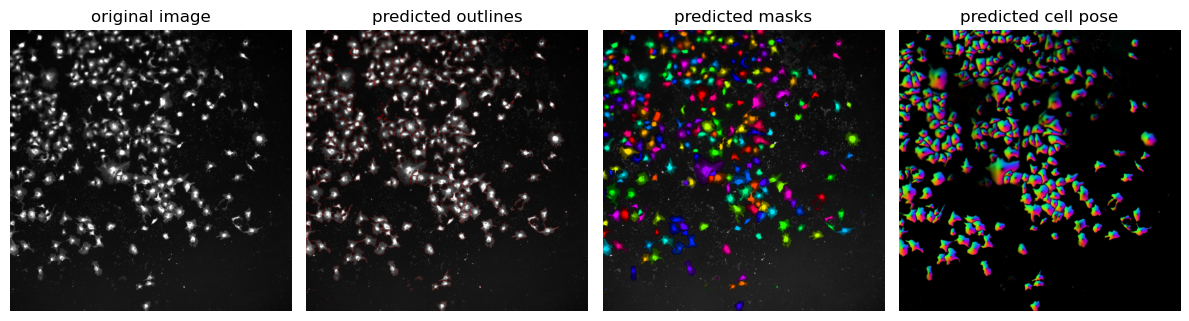

In [23]:
# Loading the data
example_name = "E3_115plate4.tif"
cell_channel, aggregate_channel, nuclei_channel = load_image_set(
    DATA_DIR, example_name
)
# Obtain cell masks for the example image set (using Cellpose)
cell_masks, cell_flows,  _ = model.eval(cell_channel, **CELLPOSE_PARAMETERS)
plot_segmentation_result(cell_channel, cell_masks, cell_flows)

Aggregates


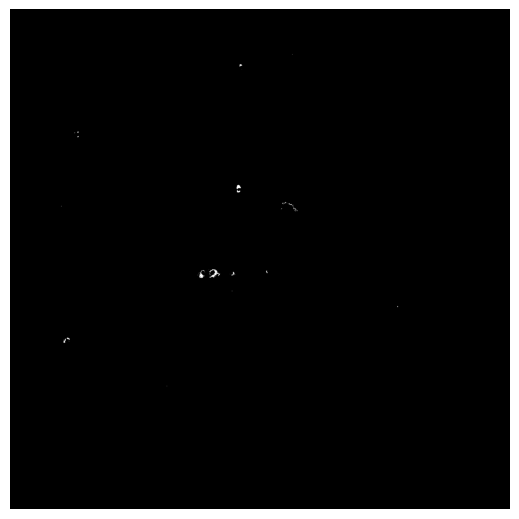

Nuclei


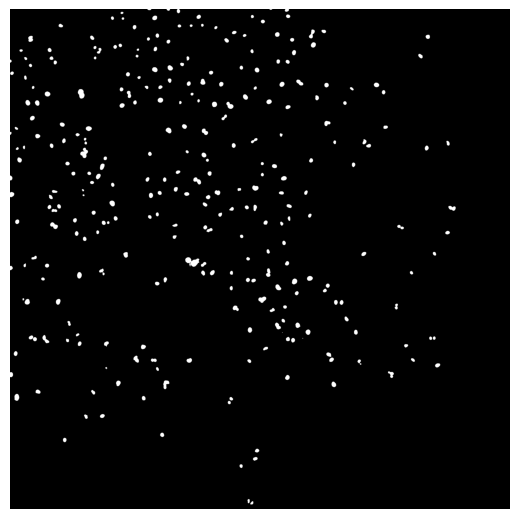

Transfected cells


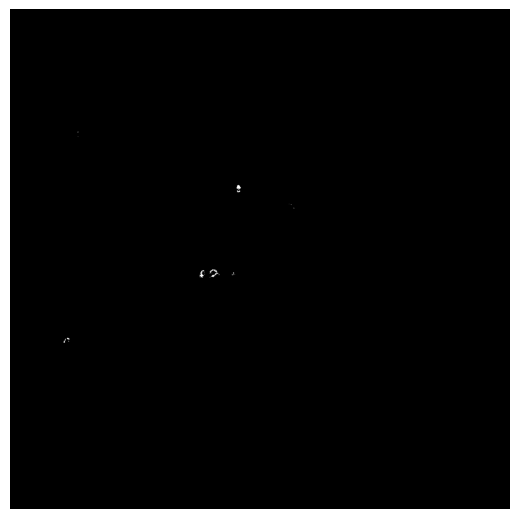

In [24]:
# Create masks for nuclear and aggregate channels using the optimal threshold
agg_binary, agg_labels = re_threshold_masks(
    aggregate_channel, cell_masks, min_size_px=2, thresh=optimal_threshold
)
nuc_binary, nuc_labels, _ = extract_masks(
    nuclei_channel, cell_masks, method="otsu", min_size_px=5
)
trans_binary, trans_labels, _ = extract_masks(
    aggregate_channel, cell_masks, method="otsu", min_size_px=2
)

# Substract nuclear masks from aggregate masks to avoid counting nuclear signal as aggregates. 
agg_binary, agg_labels = subtract_nuclear_from_aggregate(
    agg_binary, agg_labels, nuc_binary
)

print("Aggregates")
plot_aggregate_channel(agg_binary)
print("Nuclei")
plot_aggregate_channel(nuc_binary)
print("Transfected cells")
plot_aggregate_channel(trans_binary)

### Overlays

Plotting the overlays allows to visualize masks together. The parameters used in this notebook are quite permissive and some cell debris is mistakenly recognised as cells. The further filterings remove the small artifacts leaving only relevant transfected cells. 

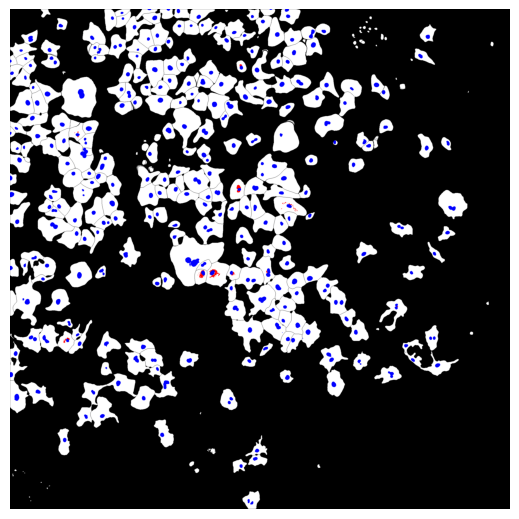

In [25]:
# Overlay the masks and outlines on the original image for visualization
outlines = utils_cell.masks_to_outlines(cell_masks)
overlay = build_overlay(
    cell_masks, nuc_labels, agg_labels, outlines
)
plot_aggregate_channel_color(overlay)

### Cell labels

Each masked cell gets a unique label to allow matching the images to the extracted data. 

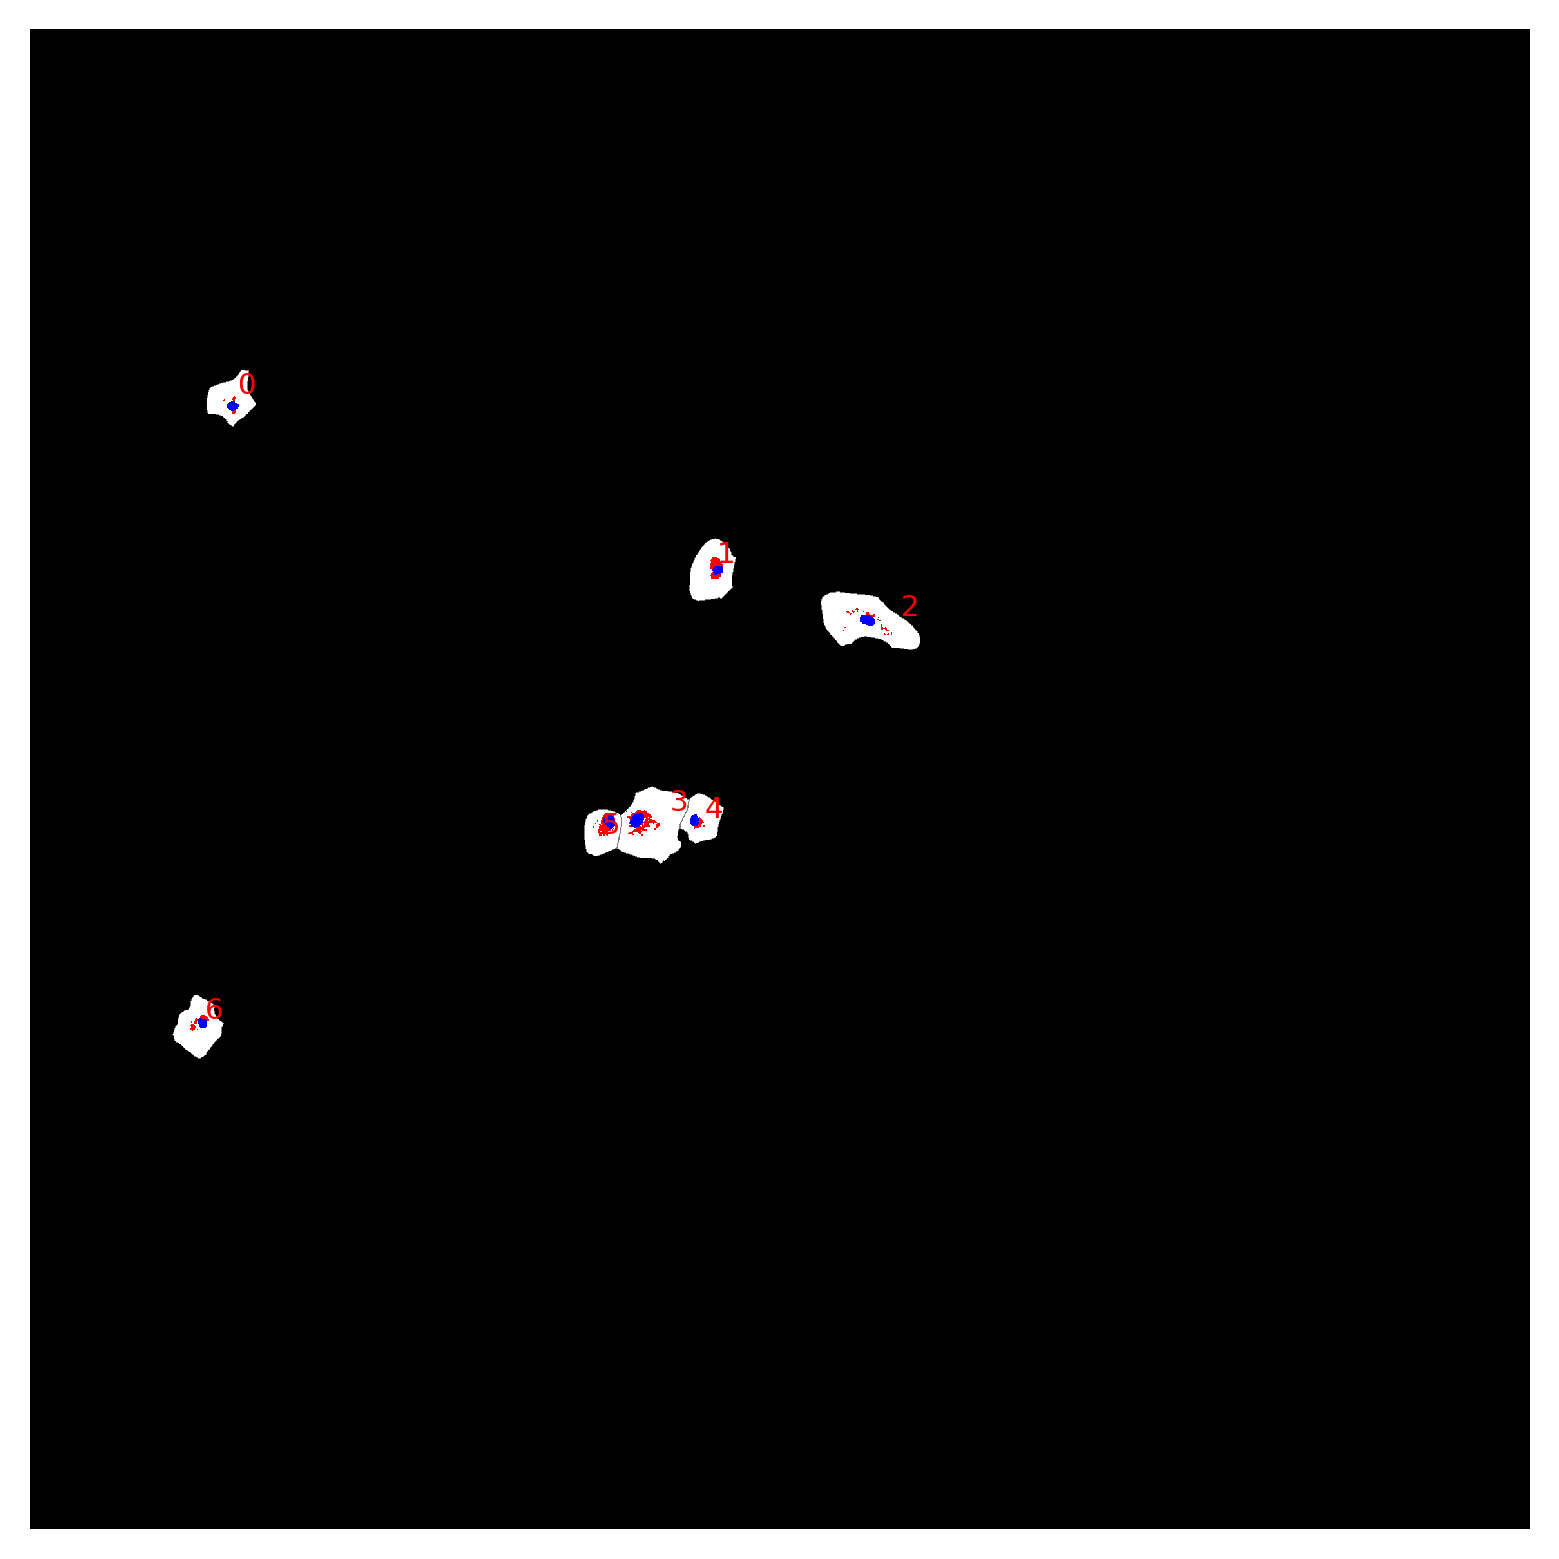

In [26]:
# Filter to keep only transfected cells and create a new overlay with only those cells numbered to track them
labels = filter_cells_by_overlap(
    cell_masks, trans_labels, nuc_labels
)
filtered_overlay = mask_overlay_to_transfected(
    overlay, cell_masks, labels
)

records: list[dict]   = []
text_mapping = {}
reverse_text_mapping = {}
for jj, metrics in enumerate(compute_cell_metrics(cell_masks, nuc_labels, agg_labels, labels)):
    records.append({
        "cell num":  jj,
        "cell area": metrics.cell_area,
        "agg area":  metrics.agg_area,
        "nuc area":  metrics.nuc_area,
        "jaccard":   metrics.jaccard,
        "cell aspect ratio": metrics.cell_aspect_ratio,
        "cell circularity": metrics.cell_circularity,
        "agg aspect ratio": metrics.agg_aspect_ratio,
        "agg circularity": metrics.agg_circularity
    })
    text_mapping[metrics.label] = jj
    reverse_text_mapping[jj] = metrics.label
    
plot_aggregate_channel_color_labelled(
    filtered_overlay, cell_masks, text_mapping
)

## Radial distribution analysis

The next section shows how to analyze the localization of the aggregates using the nucleus as cell center.
The module computes both pixels and cumulative intensity distributions. [ref1](https://link.springer.com/article/10.15252/embr.201541382) ,[ref2](https://www.nature.com/articles/s41467-024-44957-1)

In [27]:
# Radial distribution analysis for the transfected cells
radial_intensity = aggregate_channel.copy()
radial_intensity[nuc_binary != 0] = 0

nucleus_centroids = nucleus_centroids_by_cell(
    cell_masks, nuc_binary, cell_labels=labels
)
radial_distributions = compute_nucleus_centered_distribution(
    cell_masks,
    nucleus_centroids,
    agg_binary,
    radial_intensity,
    radial_bins=RADIAL_BINS,
    cell_labels=list(nucleus_centroids),
)


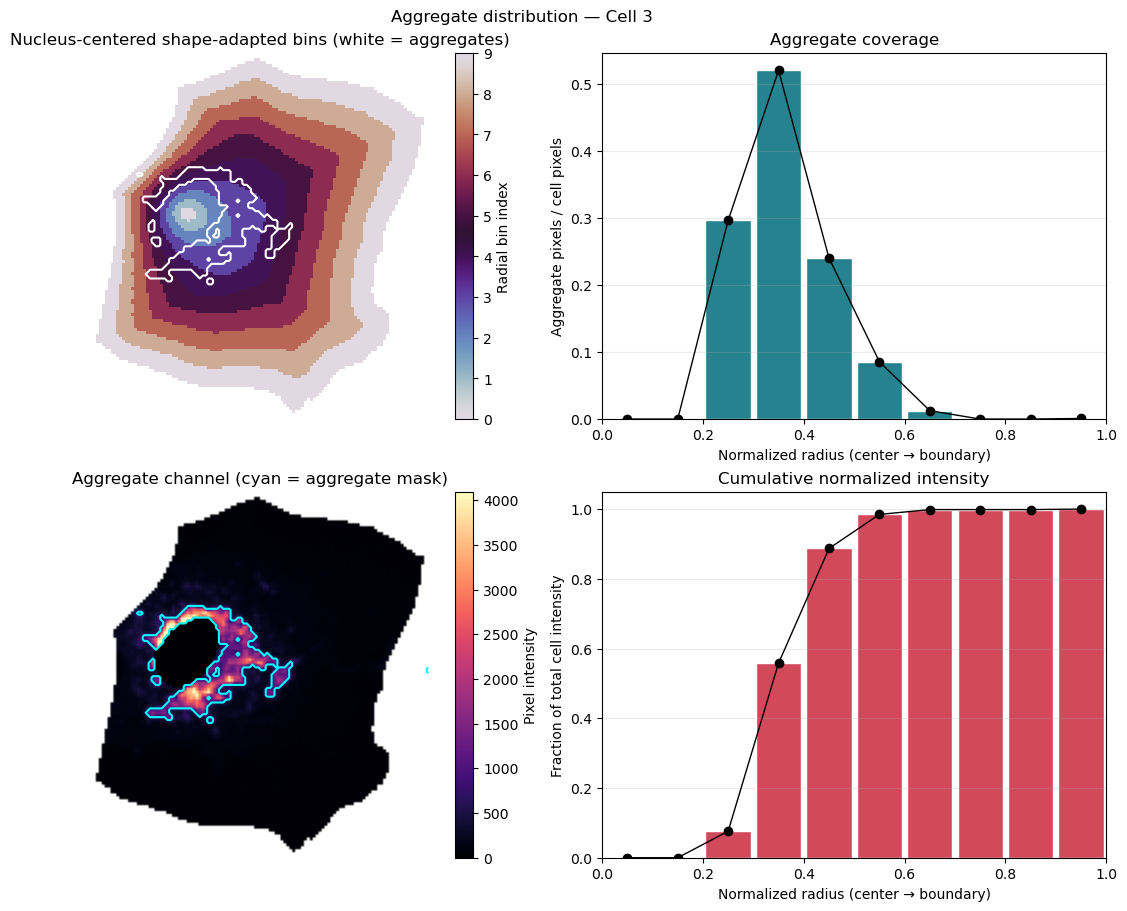

(<Figure size 1200x900 with 6 Axes>,
 {'sections': <Axes: title={'center': 'Nucleus-centered shape-adapted bins (white = aggregates)'}>,
  'channel': <Axes: title={'center': 'Aggregate channel (cyan = aggregate mask)'}>,
  'coverage': <Axes: title={'center': 'Aggregate coverage'}, xlabel='Normalized radius (center → boundary)', ylabel='Aggregate pixels / cell pixels'>,
  'intensity': <Axes: title={'center': 'Cumulative normalized intensity'}, xlabel='Normalized radius (center → boundary)', ylabel='Fraction of total cell intensity'>})

In [28]:
# Plotting of cells with their radial distributions. You can change the example_label to visualize different cells.
example_label = 3 # Change to any other cell label with aggregates to visualize its distribution
internal_label = reverse_text_mapping[example_label]
plot_nucleus_centered_distribution(
    cell_masks,
    agg_binary,
    radial_intensity,
    radial_distributions[internal_label],
    cell_name=f"Cell {example_label}"
)

In [29]:
# Show results for all cells
pd.DataFrame(records)

,cell num,cell area,agg area,nuc area,jaccard,cell aspect ratio,cell circularity,agg aspect ratio,agg circularity
0,0,4059,60,207,0.014782,1.159,0.678,1.618333,1.375333
1,1,5346,361,186,0.067527,1.458,0.790,1.463500,0.672000
2,2,9211,197,318,0.021387,2.211,0.619,inf,1.081357
3,3,9351,650,384,0.069511,1.248,0.726,inf,1.352400
4,4,3618,102,209,0.028192,1.258,0.777,inf,0.752333
5,5,3508,370,308,0.105473,1.299,0.851,inf,2.677000
6,6,4869,192,182,0.039433,1.288,0.750,inf,0.797500


In [30]:
# Show results for Radial distribution analysis for all cells
records_radial = radial_distributions_to_records(
    {example_name: radial_distributions}
)
# Change the label to transfected cells
for record in records_radial:
    record["cell_label"] = text_mapping[record["cell_label"]]

# Display results
radial_df = pd.DataFrame(records_radial)
display(radial_df)

,image_id,cell_label,centroid_row,centroid_column,radial_bin,radius_start,radius_end,section_size_pixels,aggregate_pixels,aggregate_present,aggregate_fraction,aggregate_share,intensity_sum,intensity_mean,intensity_share,cumulative_normalized_intensity
0,E3_115plate4.tif,0,584.797101,314.159420,0,0.0,0.1,19,0,False,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1,E3_115plate4.tif,0,584.797101,314.159420,1,0.1,0.2,72,0,False,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
2,E3_115plate4.tif,0,584.797101,314.159420,2,0.2,0.3,142,9,True,0.063380,0.150000,9381.0,1042.333333,0.137925,0.137925
3,E3_115plate4.tif,0,584.797101,314.159420,3,0.3,0.4,221,34,True,0.153846,0.566667,41498.0,1220.529412,0.610130,0.748056
4,E3_115plate4.tif,0,584.797101,314.159420,4,0.4,0.5,305,17,True,0.055738,0.283333,17136.0,1008.000000,0.251944,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,E3_115plate4.tif,6,1542.692308,267.324176,5,0.5,0.6,506,1,True,0.001976,0.005208,836.0,836.000000,0.001772,1.000000
66,E3_115plate4.tif,6,1542.692308,267.324176,6,0.6,0.7,611,0,False,0.000000,0.000000,0.0,0.000000,0.000000,1.000000
67,E3_115plate4.tif,6,1542.692308,267.324176,7,0.7,0.8,751,0,False,0.000000,0.000000,0.0,0.000000,0.000000,1.000000
68,E3_115plate4.tif,6,1542.692308,267.324176,8,0.8,0.9,886,0,False,0.000000,0.000000,0.0,0.000000,0.000000,1.000000


## Run the batch analysis and save inspection figures

The batch starts from the precomputed list of complete image sets, so the progress counter advances once per C1/C2/C3 set. For every set it saves segmentation, channel-mask, overlay, filtered-cell, and per-cell radial-distribution figures under `INSPECTION_DIR`. Displayed cell numbers are reassigned from zero using only the retained transfected cells; the original mask labels remain internal lookup keys.

In [16]:
image_sets = [
    "E3_048plate3.tif",
    "E3_055plate2.tif",
    "E3_088plate1.tif",
    "E3_089plate1.tif",
    "E3_115plate4.tif",
    "E3_116plate4.tif",
    "E3_117plate4.tif",
    "E3_141plate5.tif",
    "E3_142plate5.tif",
    "E3_143plate5.tif"
]


cell_records = []
radial_distributions = {}
radial_metadata = {}
cell_indices_by_image = {}
file_num = 0

for index, name in enumerate(image_sets, start=1):
    sample_id = name.split("_")[0]
    print(f"Set {index} of {len(image_sets)}: {name}")
    file_num += 1

    # Load the three aligned channels.
    img_cell, img_aggregates, img_nuclei = load_image_set(DATA_DIR, name)

    # Segment cells with Cellpose and save the labeled mask.
    cell_masks, cell_flows, _ = model.eval(img_cell, **CELLPOSE_PARAMETERS)

    # Apply the calibrated aggregate threshold.
    agg_binary, agg_labels = re_threshold_masks(
        aggregate_channel=img_aggregates,
        cell_masks=cell_masks,
        min_size_px=2,
        thresh=optimal_threshold,
    )
    nuc_binary, nuc_labels, _ = extract_masks(
        aggregate_channel=img_nuclei,
        cell_masks=cell_masks,
        method="otsu",
        min_size_px=5,
        scale=1,
    )
    trans_binary, trans_labels, _ = extract_masks(
        aggregate_channel=img_aggregates,
        cell_masks=cell_masks,
        method="otsu",
        min_size_px=2,
        scale=1,
    )

    # Remove nuclear signal and compose the categorical overlay.
    agg_binary, agg_labels = subtract_nuclear_from_aggregate(
        agg_binary, agg_labels, nuc_binary
    )

    # Retain cells containing both transfection and nuclear signal.
    transfected_labels = filter_cells_by_overlap(
        cell_masks, trans_labels, nuc_labels
    )
    # The overlap filter excludes cells without nuclear signal.
    # Store the established per-cell measurements.
    metrics_for_image = compute_cell_metrics(
        cell_masks, nuc_labels, agg_labels, transfected_labels
    )
    # Map original mask labels to consecutive displayed indices using
    # only the retained transfected cells, as in the single-image walkthrough.
    cell_index_by_label = {
        metrics.label: cell_num
        for cell_num, metrics in enumerate(metrics_for_image)
    }
    cell_indices_by_image[name] = cell_index_by_label
    for cell_num, metrics in enumerate(metrics_for_image):
        cell_records.append({
            "sample_id": sample_id,
            "File Name": name,
            "Img number": file_num,
            "cell num": cell_num,
            "cell label": metrics.label,
            "cell area": metrics.cell_area,
            "agg area": metrics.agg_area,
            "nuc area": metrics.nuc_area,
            "jaccard": metrics.jaccard,
            "cell aspect ratio": metrics.cell_aspect_ratio,
            "cell circularity": metrics.cell_circularity,
            "agg aspect ratio": metrics.agg_aspect_ratio,
            "agg circularity": metrics.agg_circularity,
        })

    # Save the same quality-control views shown in the walkthrough.
    image_inspection_dir = INSPECTION_DIR / Path(name).stem
    image_inspection_dir.mkdir(parents=True, exist_ok=True)
    outlines = utils_cell.masks_to_outlines(cell_masks)
    overlay = build_overlay(cell_masks, nuc_labels, agg_labels, outlines)
    filtered_overlay = mask_overlay_to_transfected(
        overlay, cell_masks, transfected_labels
    )
    plot_segmentation_result(
        img_cell, cell_masks, cell_flows,
        save_path=image_inspection_dir / "cell_segmentation.png",
    )
    plot_aggregate_channel(
        agg_binary, save_path=image_inspection_dir / "aggregate_mask.png"
    )
    plot_aggregate_channel(
        nuc_binary, save_path=image_inspection_dir / "nuclear_mask.png"
    )
    plot_aggregate_channel_color(
        overlay, save_path=image_inspection_dir / "all_cells_overlay.png"
    )
    plot_aggregate_channel_color_labelled(
        filtered_overlay,
        cell_masks,
        cell_index_by_label,
        save_path=image_inspection_dir / "transfected_cells.png",
    )


    #For radial analysis, zero nuclear intensity before measuring the retained cells.
    radial_intensity = img_aggregates.copy()
    radial_intensity[nuc_binary != 0] = 0

    # Center each retained cell's radial field on its nuclear signal.
    nucleus_centroids = nucleus_centroids_by_cell(
        cell_masks, nuc_binary, cell_labels=transfected_labels
    )
    # Cells without a nucleus centroid are omitted from radial analysis.
    distributions = compute_nucleus_centered_distribution(
        cell_masks=cell_masks,
        nucleus_centroids=nucleus_centroids,
        aggregate_mask=agg_binary,
        aggregate_channel=radial_intensity,
        radial_bins=RADIAL_BINS,
        cell_labels=list(nucleus_centroids),
    )
    radial_distributions[name] = distributions
    radial_metadata[name] = {
        "sample_id": sample_id,
        "image_number": file_num,
    }

    # Save one radial diagnostic per retained transfected cell.
    for internal_label, distribution in distributions.items():
        cell_index = cell_index_by_label[internal_label]
        plot_nucleus_centered_distribution(
            cell_masks,
            agg_binary,
            radial_intensity,
            distribution,
            save_path=(
                image_inspection_dir / f"radial_cell_{cell_index}.png"
            ),
            show=False,
            cell_name=f"Cell {cell_index}",
        )



Set 1 of 10: E3_048plate3.tif
Set 2 of 10: E3_055plate2.tif
Set 3 of 10: E3_088plate1.tif
Set 4 of 10: E3_089plate1.tif
Set 5 of 10: E3_115plate4.tif
Set 6 of 10: E3_116plate4.tif
Set 7 of 10: E3_117plate4.tif
Set 8 of 10: E3_141plate5.tif
Set 9 of 10: E3_142plate5.tif
Set 10 of 10: E3_143plate5.tif


## Save the analysis tables

The original cell-level measurements and the new radial measurements remain separate. The package utility handles radial columns, cumulative intensity, metadata repetition, and CSV writing.

In [17]:
cell_data = pd.DataFrame(cell_records)
cell_data.to_csv(CELL_CSV, index=False)
radial_records = radial_distributions_to_records(
    radial_distributions, metadata_by_image=radial_metadata
)
# Replace internal mask labels with the same transfected-cell indices
# displayed in the inspection figures.
for record in radial_records:
    record["cell_label"] = cell_indices_by_image[record["image_id"]][
        record["cell_label"]
    ]
radial_data = pd.DataFrame(radial_records)
radial_data.to_csv(RADIAL_CSV, index=False)
print(f"Saved {len(cell_data)} cell rows to {CELL_CSV}")
print(f"Saved {len(radial_data)} radial rows to {RADIAL_CSV}")
display(cell_data.head())
display(radial_data.head())


Saved 130 cell rows to /media/ograciac/light-roast/ograciac/MorroCells/parsho/notebooks/data/tutorial_results/final_data.csv
Saved 1300 radial rows to /media/ograciac/light-roast/ograciac/MorroCells/parsho/notebooks/data/tutorial_results/radial_distribution.csv


,sample_id,File Name,Img number,cell num,cell label,cell area,agg area,nuc area,jaccard,cell aspect ratio,cell circularity,agg aspect ratio,agg circularity
0,E3,E3_048plate3.tif,1,0,10,2085,174,349,0.083453,1.244,0.802,inf,0.202000
1,E3,E3_048plate3.tif,1,1,106,2362,313,206,0.132515,2.234,0.527,1.724,0.531500
2,E3,E3_048plate3.tif,1,2,184,3088,85,428,0.027526,1.936,0.712,inf,0.523667
3,E3,E3_048plate3.tif,1,3,319,3680,0,460,0.000000,1.168,0.820,0.000,0.000000
4,E3,E3_048plate3.tif,1,4,398,878,0,192,0.000000,1.367,0.727,0.000,0.000000


,image_id,sample_id,image_number,cell_label,centroid_row,centroid_column,radial_bin,radius_start,radius_end,section_size_pixels,aggregate_pixels,aggregate_present,aggregate_fraction,aggregate_share,intensity_sum,intensity_mean,intensity_share,cumulative_normalized_intensity
0,E3_048plate3.tif,E3,1,0,90.733524,168.332378,0,0.0,0.1,9,9,True,1.000000,0.051724,23646.0,2627.333333,0.059602,0.059602
1,E3_048plate3.tif,E3,1,0,90.733524,168.332378,1,0.1,0.2,38,28,True,0.736842,0.160920,56652.0,2023.285714,0.142796,0.202398
2,E3_048plate3.tif,E3,1,0,90.733524,168.332378,2,0.2,0.3,87,56,True,0.643678,0.321839,132286.0,2362.250000,0.333438,0.535836
3,E3_048plate3.tif,E3,1,0,90.733524,168.332378,3,0.3,0.4,118,30,True,0.254237,0.172414,65530.0,2184.333333,0.165174,0.701011
4,E3_048plate3.tif,E3,1,0,90.733524,168.332378,4,0.4,0.5,159,19,True,0.119497,0.109195,45181.0,2377.947368,0.113883,0.814893


## Outputs

The walkthrough displays Cellpose and Parsho quality-control figures. The batch saves Cellpose, aggregate, and nuclear masks; inspection figures under `inspection_images/<image name>/`; and the `final_data.csv` and `radial_distribution.csv` tables. Cell indices in the filtered overlays, radial figure filenames/titles, and radial CSV all refer only to retained transfected cells.